In [1]:
# import libraries
import numpy as np
import scipy as sp
import pickle
import pydtmc
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [2]:
# Categorization functions

def categorize_diffusers(coordinates):
    """Recieves a coordinates array of shape [n_diffusers, 3], and returns an array of shape [n_diffusers],
    Where each entry is in the range [0,9] (inclusive). Which signify the following state states:
    0: Cytoplasm
    1-8: NPC radial segmets
    9: Nucleus
    """
    n_diffusers = coordinates.shape[0]
    categorized_coordinates = np.zeros(shape=(n_diffusers))
    
    # Create masks
    cyto_mask = coordinates[:, 2] >= 15
    nuc_mask = coordinates[:, 2] <= -15
    
    # apply masks
    angle = np.arctan2(coordinates[:, 1], coordinates[:, 0]) + np.pi
    eighth = np.floor(angle / (np.pi * 0.25)) + 1
    eighth[eighth == 9] = 8
    categorized_coordinates[((~cyto_mask) & (~nuc_mask))] = eighth[((~cyto_mask) & (~nuc_mask))]
    categorized_coordinates[cyto_mask] = 0
    categorized_coordinates[nuc_mask] = 9
    
    return categorized_coordinates


def categorize_diffusers2(coordinates, angle_offset=0):
    """
    Recieves a coordinates array of shape [n_diffusers, 3], and returns an array of shape [n_diffusers],
    Where each entry is in the range [0,17] (inclusive). Which signify the following state states:
    0: Cytoplasm
    1-8: NPC radial segmets (cytoplasm half)
    9-16: NPC radial segmets (nucleus half)
    17: Nucleus
    angle_offset should be a number between 0 and 0.25*pi, signifying the angle offset for spoke barriers.
    """
    n_diffusers = coordinates.shape[0]
    categorized_coordinates = np.zeros(shape=(n_diffusers))
    
    # Create masks
    cyto_mask = coordinates[:, 2] >= 15
    nuc_mask = coordinates[:, 2] <= -15
    cyto_half_mask = coordinates[:, 2] >= 0
    
    # apply masks
    angle = np.arctan2(coordinates[:, 1], coordinates[:, 0]) + np.pi + angle_offset
    angle = np.mod(angle, 2 * np.pi)
    eighth = np.floor(angle / (np.pi * 0.25)) + 1
    eighth[eighth == 9] = 8
    categorized_coordinates[((~cyto_mask) & (~nuc_mask) & cyto_half_mask)] = eighth[((~cyto_mask) & (~nuc_mask) & cyto_half_mask)]
    categorized_coordinates[((~cyto_mask) & (~nuc_mask) & (~cyto_half_mask))] = eighth[((~cyto_mask) & (~nuc_mask) & (~cyto_half_mask))] + 8
    categorized_coordinates[cyto_mask] = 0
    categorized_coordinates[nuc_mask] = 17
    
    return categorized_coordinates

def categorize_diffusers3(coordinates, angle_offset=0):
    """
    Recieves a coordinates array of shape [n_diffusers, 3], and returns an array of shape [n_diffusers],
    Where each entry is in the range [0,25] (inclusive). Which signify the following state states:
    0: Cytoplasm
    1-8: NPC radial segmets (cytoplasm third)
    9-16: NPC radial segments (center third)
    17-24: NPC radial segmets (nucleus third)
    25: Nucleus
    angle_offset should be a number between 0 and 0.25*pi, signifying the angle offset for spoke barriers.
    """
    n_diffusers = coordinates.shape[0]
    categorized_coordinates = np.zeros(shape=(n_diffusers))
    
    # Create masks
    cyto_mask = coordinates[:, 2] >= 15
    nuc_mask = coordinates[:, 2] <= -15
    cyto_third_mask = coordinates[:, 2] >= 5
    nuc_third_mask = coordinates[:, 2] <= -5
    center_third_mask = ~cyto_third_mask & ~nuc_third_mask
    
    
    # apply masks
    angle = np.arctan2(coordinates[:, 1], coordinates[:, 0]) + np.pi + angle_offset
    angle = np.mod(angle, 2 * np.pi)
    eighth = np.floor(angle / (np.pi * 0.25)) + 1
    eighth[eighth == 9] = 8
    categorized_coordinates[((~cyto_mask) & (~nuc_mask) & cyto_third_mask)] = eighth[((~cyto_mask) & (~nuc_mask) & cyto_third_mask)]
    categorized_coordinates[((~cyto_mask) & (~nuc_mask) & center_third_mask)] = eighth[((~cyto_mask) & (~nuc_mask) & center_third_mask)] + 8
    categorized_coordinates[((~cyto_mask) & (~nuc_mask) & nuc_third_mask)] = eighth[((~cyto_mask) & (~nuc_mask) & nuc_third_mask)] + 16
    categorized_coordinates[cyto_mask] = 0
    categorized_coordinates[nuc_mask] = 25
    
    return categorized_coordinates

    
def categorize_diffusers_over_time(trajectories, version, angle_offset, step=1):
    n_diffusers = trajectories.shape[0]
    n_t = trajectories.shape[2]
    n_columns = len(range(0, n_t, step))
    categorized_trajectories = np.zeros(shape=(n_diffusers, n_columns))
    if version == 1:
        for t in range(0, n_t, step):
            categorized_trajectories[:,int(t / step)] = categorize_diffusers(trajectories[:, :, t])
    elif version == 2:
        for t in range(0, n_t, step):
            categorized_trajectories[:,int(t / step)] = categorize_diffusers2(trajectories[:, :, t], angle_offset=angle_offset)
    elif version == 3:
        for t in range(0, n_t, step):
            categorized_trajectories[:,int(t / step)] = categorize_diffusers3(trajectories[:, :, t], angle_offset=angle_offset)
    else:
        raise Exception("Invalid Version")
    return categorized_trajectories

In [3]:
# Transition matrix functions

from numpy import float64


def normalize_rows(counts_matrix):
    transition_matrix = np.zeros_like(counts_matrix)
    n_states = counts_matrix.shape[0]
    for i in range(n_states):
        row_sum = np.sum(counts_matrix[i, :])
        if row_sum == 0:
            print(f"Row sum is 0, setting row {i} to 0    :( ")
            transition_matrix[i, :] = 0
            continue
        transition_matrix[i, :] = counts_matrix[i, :] / row_sum
    return transition_matrix
    

def calc_counts_matrix(categorized_trajectories, n_states, init_1 = False):
    if init_1: counts_matrix = np.ones(shape=(n_states,n_states))
    else: counts_matrix = np.zeros(shape=(n_states,n_states))
    n_diffusers = categorized_trajectories.shape[0]
    n_t = categorized_trajectories.shape[1]
    
    for i in range(n_diffusers):
        for t in range(n_t - 1):
            first = int(categorized_trajectories[i,t])
            second = int(categorized_trajectories[i,t+1])
            counts_matrix[first, second] += 1
    return counts_matrix

def calc_transition_matrix(categorized_trajectories, n_states):
    counts_matrix = calc_counts_matrix(categorized_trajectories, n_states)
    transition_matrix = normalize_rows(counts_matrix)
    return transition_matrix

def calc_radialized_transition_matrix(categorized_trajectories, categorization_version, init_1 = False):
    """ 
    Given categorized trajectories of version 3, computes a transition matrix where the transition for each spoke is the same,
    shifted radially, through averaging.
    """
    if categorization_version != 3:
        raise Exception("Invalid Version")
    counts_matrix = calc_counts_matrix(categorized_trajectories, 26, init_1)
    avgd_coords = []
    orig = np.array(range(8))
    for i in range(8):
        avgd_coords.append((orig + i) % 8 + 1)
        avgd_coords.append((orig + i) % 8 + 9)
        avgd_coords.append((orig + i) % 8 + 17)
    for i in range(len(avgd_coords)):
        counts_matrix[avgd_coords[i], avgd_coords[i]] = np.mean(counts_matrix[avgd_coords[i], avgd_coords[i]])
    for to_avg_range in [list(range(1, 9)), list(range(9, 17)), list(range(17, 25))]:
        counts_matrix[to_avg_range, 0] = np.mean(counts_matrix[to_avg_range, 0])
        counts_matrix[to_avg_range, 25] = np.mean(counts_matrix[to_avg_range, 25])
        counts_matrix[0, to_avg_range] = np.mean(counts_matrix[0, to_avg_range])
        counts_matrix[25, to_avg_range] = np.mean(counts_matrix[25, to_avg_range])
    transition_matrix = normalize_rows(counts_matrix)
    return transition_matrix
    

def infinitesimal_generator(P, dt=1.0):
    """
    Estimate the infinitesimal generator matrix Q from transition matrix P
    Implementation similar to: https://transitionmatrix.readthedocs.io/en/latest/_modules/transitionMatrix/model.html#TransitionMatrix.generator
    Units of Q are rate, i.e. 1/time. 
    expm(Q * dt) will result in P.
    
    Examples:
    If the units of P are transition probablities per 100ns,
    then the units of Q will be the transition rate 1 / (100ns * dt).
    
    
    Parameters:
    P : numpy.ndarray
        Transition matrix
    dt : float, optional
        The time scale parameter. 
    
    Returns:
    numpy.ndarray
        Infinitesimal generator matrix Q. 
    """
    return sp.linalg.logm(P) / dt
    
def transition_from_generator(Q, dt=1.0):
    return sp.linalg.expm(Q * dt)

def visualize_transition_matrix(data, ticks_list, title, vlines=None, hlines=None,
                                cbar_label=r'$Log_{10} (Pr[i \to j])$', suptitle="Spatial Transition Matrix",
                                cmap="jet", diverge_colors_around_0=False, first_and_last_factor=1):
        
    # Expand first and last rows
    first_row_repeated = np.tile(data[0, :], (first_and_last_factor-1, 1))
    data = np.append(first_row_repeated, data, axis=0)
    first_col_repeated = np.tile(data[:, 0], (first_and_last_factor-1, 1))
    data = np.append(first_col_repeated.T, data, axis=1)
    last_row_repeated = np.tile(data[-1, :], (first_and_last_factor-1, 1))
    data = np.append(data, last_row_repeated, axis=0)
    last_col_repeated = np.tile(data[:, -1], (first_and_last_factor-1, 1))
    data = np.append(data, last_col_repeated.T, axis=1)
    
    if diverge_colors_around_0:
        plt.imshow(data, cmap=cmap, interpolation='nearest', norm=TwoSlopeNorm(0))
    else:
        plt.imshow(data, cmap=cmap, interpolation='nearest')
    
    # Set ticks
    tick_positions = np.array(range(len(ticks_list)), dtype=float64)
    first_pos = (first_and_last_factor - 1) / 2
    tick_positions += first_and_last_factor - 1
    tick_positions[0] = first_pos
    tick_positions[-1] += first_pos
    plt.xticks(tick_positions, ticks_list, rotation="vertical")
    plt.yticks(tick_positions, ticks_list)
    
    # add v and h lines
    if vlines is not None: plt.vlines(np.array(vlines) + first_and_last_factor - 1, ymin=-0.5, ymax=data.shape[0]-0.5, colors="black")
    if hlines is not None: plt.hlines(np.array(hlines) + first_and_last_factor - 1, xmin=-0.5, xmax=data.shape[1]-0.5, colors="black")
    # set labels and titles
    plt.xlabel("To") # checked this
    plt.ylabel("From")
    plt.suptitle(suptitle)
    plt.title(title)
    # add colorbar
    cbar = plt.colorbar()
    cbar.set_label(cbar_label)
    plt.show()


In [4]:
# Load data

with open(f"data/merged/110-160.pickle", "rb") as f:
    trajectories = pickle.load(f)

# with open("data/spatial_markov_chain_data.pickle", "rb") as f:
#     trajectories = pickle.load(f)

In [5]:
# Process data
categorized_trajectories = categorize_diffusers_over_time(trajectories, 1, 0)
categorized_trajectories2 = categorize_diffusers_over_time(trajectories, 2, 0)
categorized_trajectories3 = categorize_diffusers_over_time(trajectories, 3, 0)
# categorized_passed = categorize_diffusers_over_time(trajectories[passed], 3, 0)

# Sanity check: Which NTRs fully passed through the NPC?
passed = []
for i in range(categorized_trajectories.shape[0]):
    if 0 in categorized_trajectories[i, :] and 9 in categorized_trajectories[i, :]:
        passed.append(i)
print(passed)
print(len(passed))

[60, 269, 357, 438, 512, 603, 654, 676, 694, 696, 810, 851, 948, 1020, 1074, 1186, 1196, 1203, 1220, 1269, 1311, 1656, 1660, 1849, 1867, 1913, 1966, 2032, 2156, 2294, 2436, 2627, 2653, 2706, 2769, 2951, 2965, 3067, 3213, 3367, 3468, 3478, 3560, 3573, 3607, 3685, 3789, 3834, 3857, 3906, 3913, 4033, 4042, 4063, 4181, 4203, 4206, 4357, 4402, 4426, 4511, 4544, 4561, 4682, 4728, 4734, 4800, 4819, 4910, 5262, 5300, 5404, 5435, 5495, 5605, 5682, 5691, 5706, 5754, 5759, 5783, 5820, 5834, 5849, 5908, 5961, 6096, 6131, 6159, 6160, 6186, 6219, 6245, 6351, 6466, 6617, 6700, 6761, 6794, 6840, 6888, 6916, 6950, 6966, 7063, 7087, 7134, 7154, 7188, 7191, 7245, 7284, 7317, 7320, 7385, 7415, 7464, 7468, 7544, 7573, 7574, 7608, 7688, 7819, 7867, 7943, 8070, 8138, 8152, 8163, 8276, 8409, 8432, 8446, 8570, 8572, 8608, 8653, 8670, 8676, 8776, 8849, 8863, 8870, 8880, 8914, 8930, 8953, 9014, 9032, 9063, 9073, 9074, 9078, 9087, 9107, 9185, 9242, 9243, 9346, 9425, 9426, 9453, 9553, 9561, 9575, 9617, 9642, 9753,

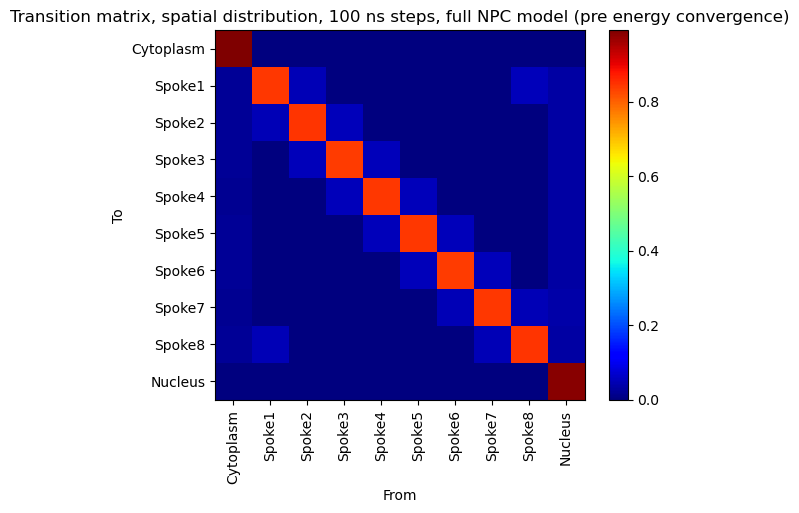

In [16]:
data = calc_transition_matrix(categorized_trajectories, 10)
ticks_list = ["Cytoplasm", "Spoke1", "Spoke2", "Spoke3","Spoke4","Spoke5","Spoke6","Spoke7","Spoke8", "Nucleus"]
visualize_transition_matrix(data, ticks_list, "Transition matrix, spatial distribution, 40 sims (110 us to 130 us), 100 ns steps")

/tmp/ipykernel_93808/79952190.py:5: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(transition_matrix2), cmap='jet', interpolation='nearest')


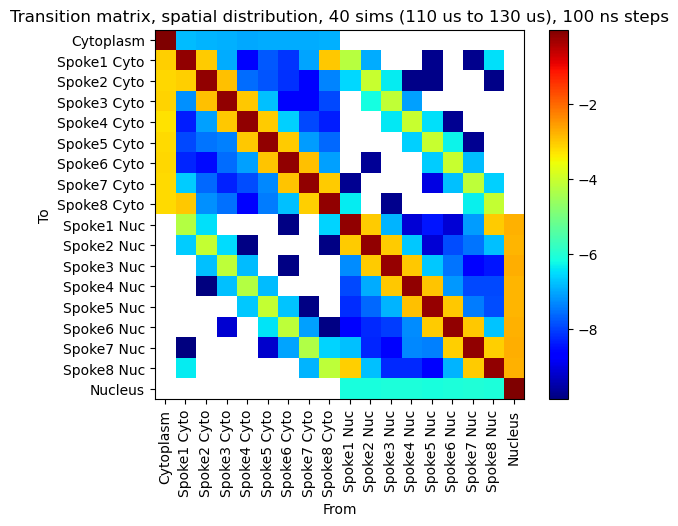

In [20]:
transition_matrix2 = calc_transition_matrix(categorized_trajectories2, 18)
ticks_list = ["Cytoplasm", "Spoke1 Cyto", "Spoke2 Cyto", "Spoke3 Cyto","Spoke4 Cyto","Spoke5 Cyto","Spoke6 Cyto","Spoke7 Cyto","Spoke8 Cyto", "Spoke1 Nuc", "Spoke2 Nuc", "Spoke3 Nuc","Spoke4 Nuc","Spoke5 Nuc","Spoke6 Nuc","Spoke7 Nuc","Spoke8 Nuc", "Nucleus"]
visualize_transition_matrix(np.log(transition_matrix2), ticks_list, "Transition matrix, spatial distribution, 40 sims (110 us to 130 us), 100 ns steps")

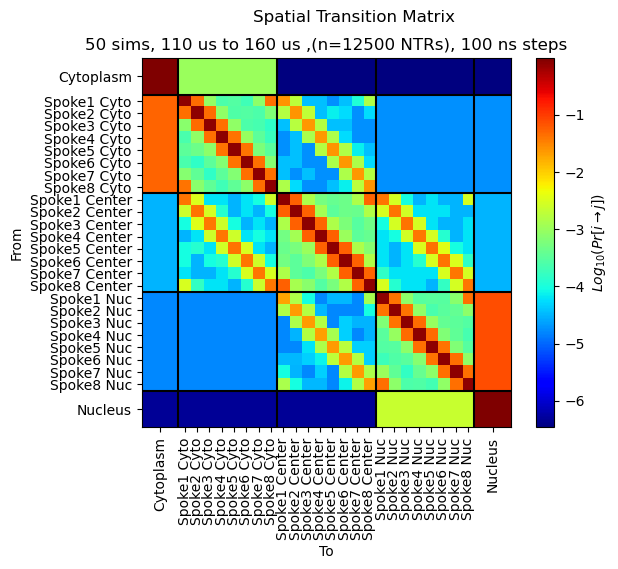

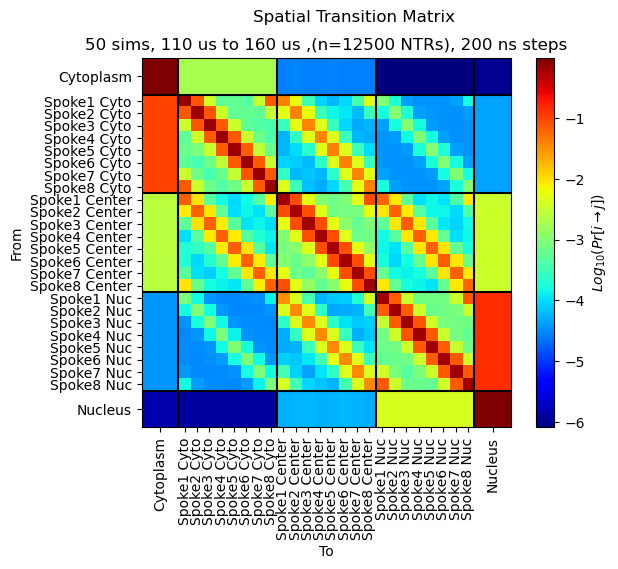

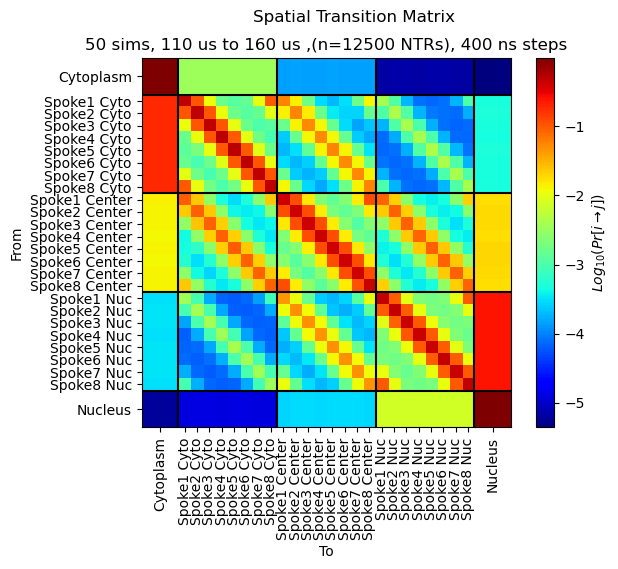

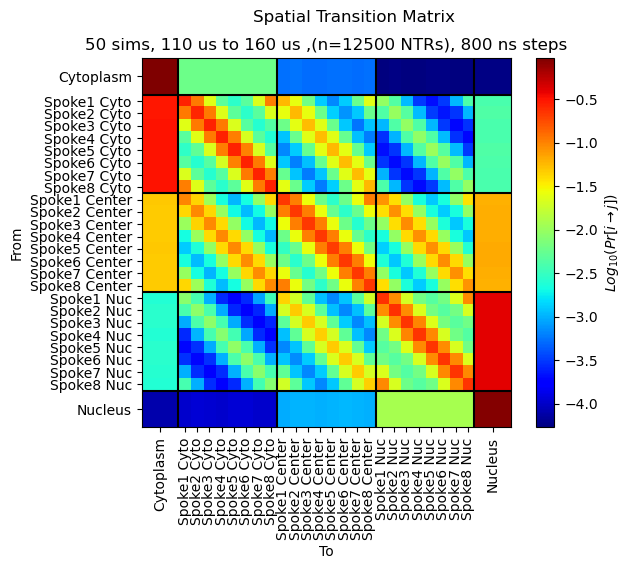

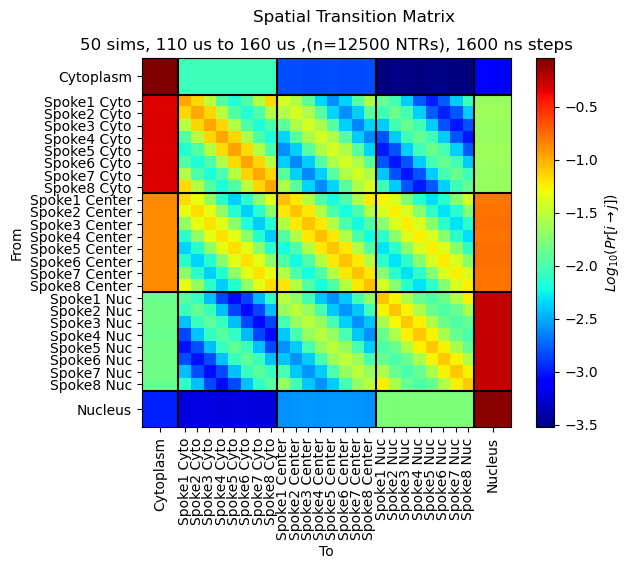

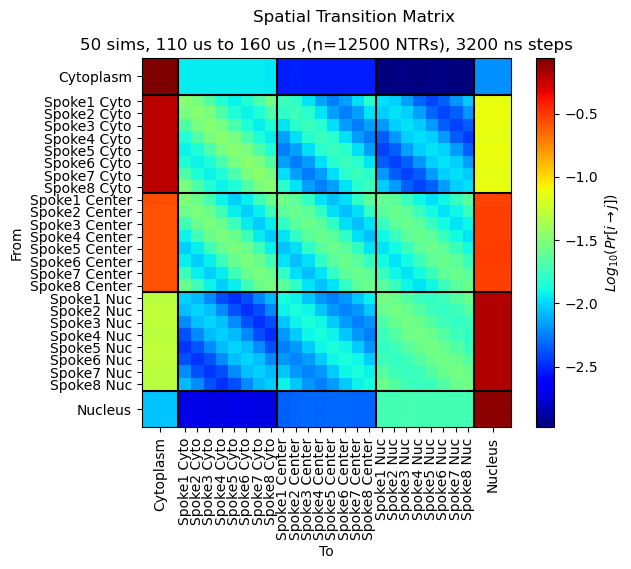

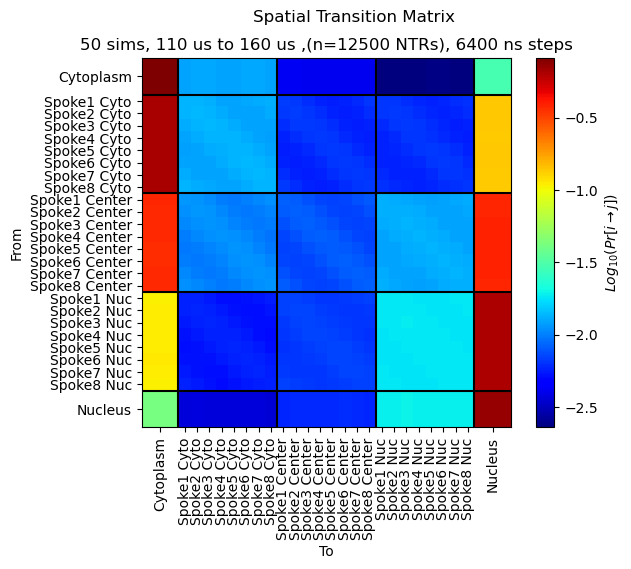

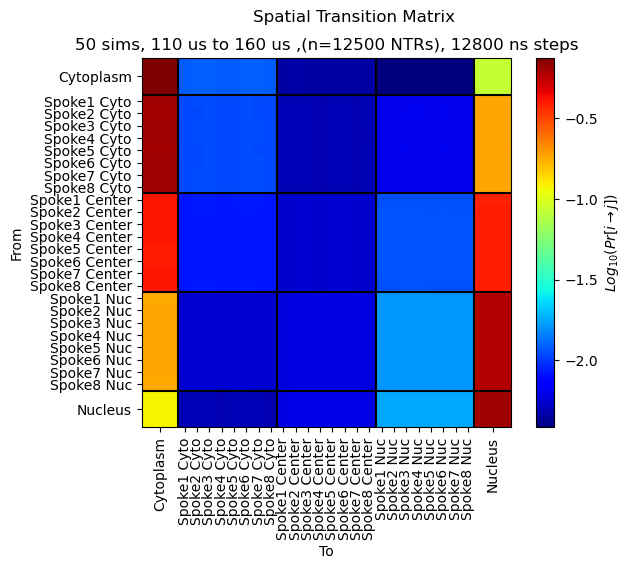

In [23]:
categorized_trajectories3 = categorize_diffusers_over_time(trajectories, 3, 0)
transition_matrix3 = calc_radialized_transition_matrix(categorized_trajectories3, 3, True)
# transition_passed = calc_transition_matrix(categorized_passed, 26)
ticks_list = ["Cytoplasm", "Spoke1 Cyto", "Spoke2 Cyto", "Spoke3 Cyto","Spoke4 Cyto","Spoke5 Cyto","Spoke6 Cyto","Spoke7 Cyto","Spoke8 Cyto", "Spoke1 Center", "Spoke2 Center", "Spoke3 Center","Spoke4 Center","Spoke5 Center","Spoke6 Center","Spoke7 Center","Spoke8 Center","Spoke1 Nuc", "Spoke2 Nuc", "Spoke3 Nuc","Spoke4 Nuc","Spoke5 Nuc","Spoke6 Nuc","Spoke7 Nuc","Spoke8 Nuc", "Nucleus"]
vlines = [0.5, 8.5, 16.5, 24.5]
hlines = vlines
for i in [1 , 2, 4, 8, 16, 32, 64, 128]:
    visualize_transition_matrix(np.log10(np.linalg.matrix_power(transition_matrix3, i)),
                                ticks_list,
                                f"50 sims, 110 us to 160 us ,(n={250*50} NTRs), {i*100} ns steps",
                                vlines,
                                hlines,
                                first_and_last_factor=3)
    # Q = infinitesimal_generator(np.linalg.matrix_power(transition_matrix3, i), i)
    # visualize_transition_matrix(Q,
    #                         ticks_list,
    #                         f"50 sims, 110 us to 160 us ,(n={250*50} NTRs), {i*100} ns steps",
    #                         vlines, hlines,
    #                         cbar_label=r'Signed $Log_{10} (1 / 100ns)$',
    #                         suptitle="Estimated generator matrix",
    #                         cmap="RdBu",
    #                         diverge_colors_around_0=True)    

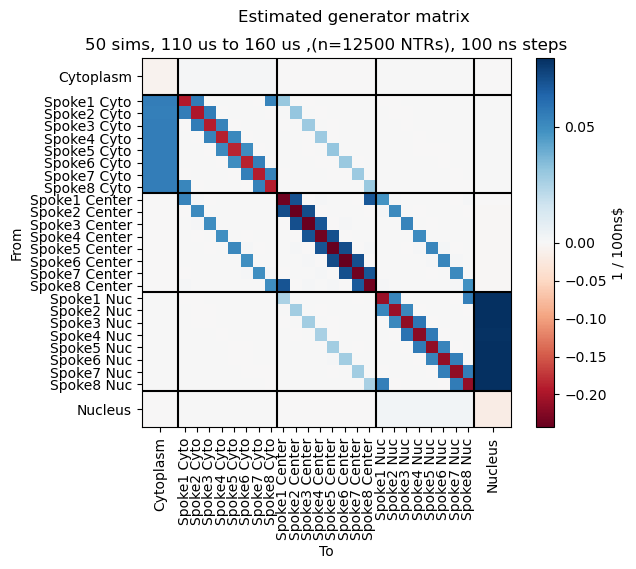

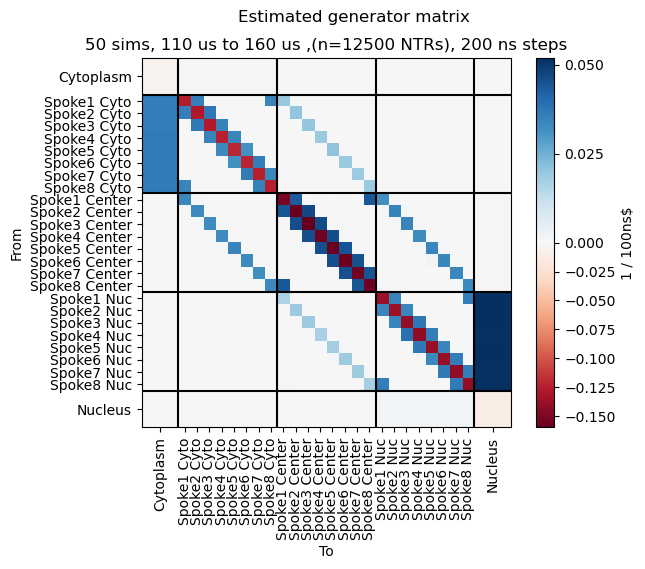

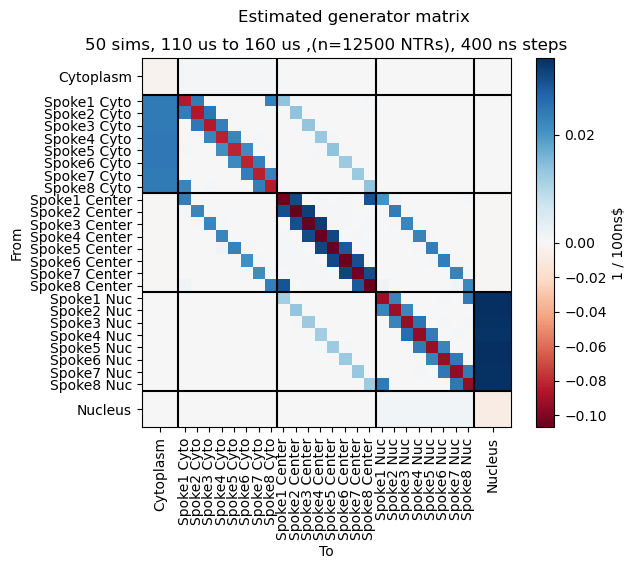

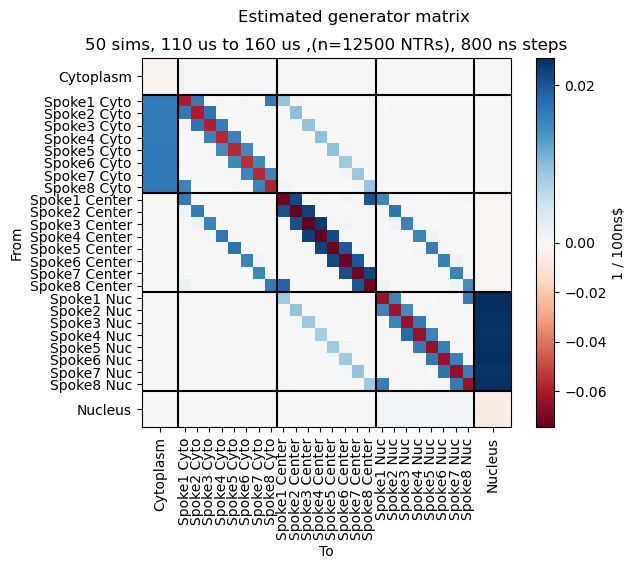

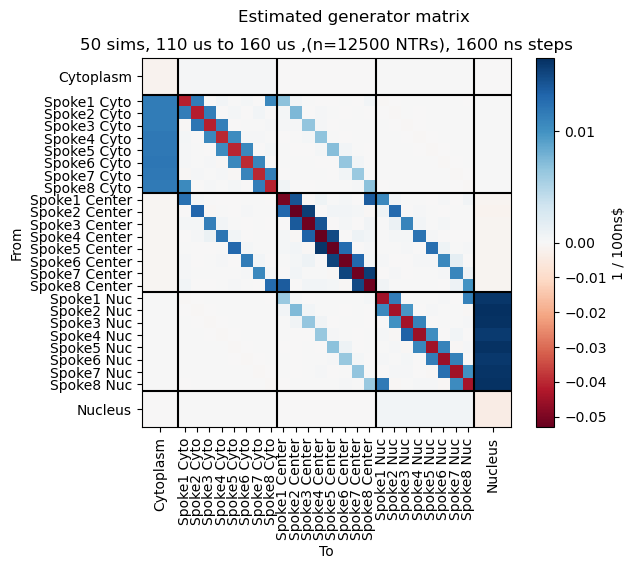

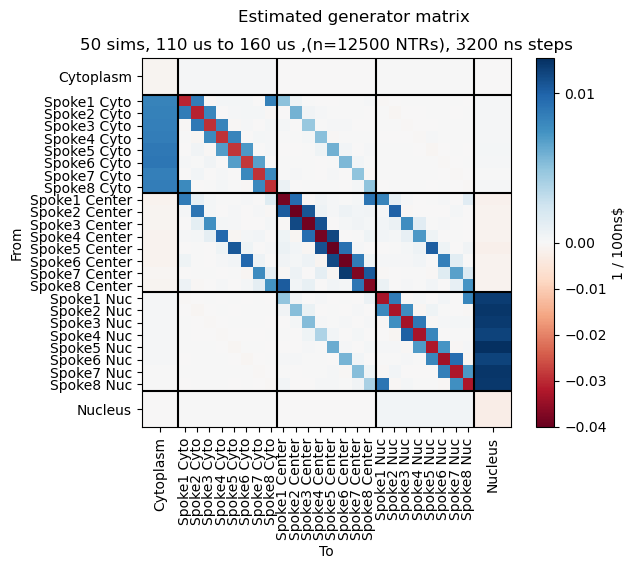

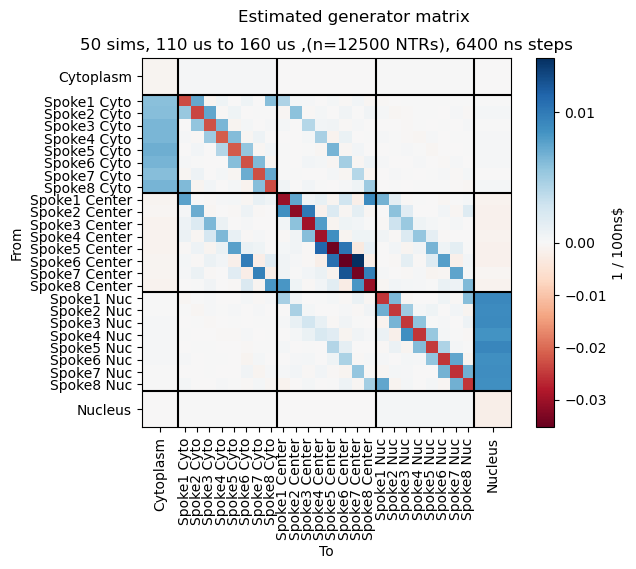

TypeError: Image data of dtype complex128 cannot be converted to float

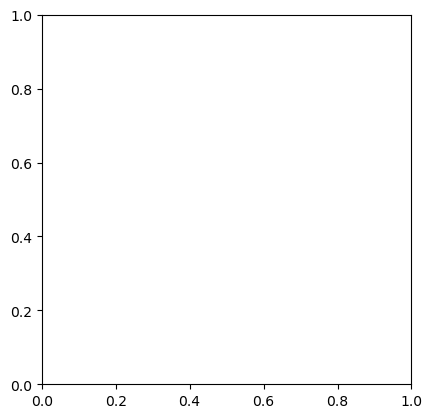

In [ ]:
ticks_list = ["Cytoplasm", "Spoke1 Cyto", "Spoke2 Cyto", "Spoke3 Cyto","Spoke4 Cyto","Spoke5 Cyto","Spoke6 Cyto","Spoke7 Cyto","Spoke8 Cyto", "Spoke1 Center", "Spoke2 Center", "Spoke3 Center","Spoke4 Center","Spoke5 Center","Spoke6 Center","Spoke7 Center","Spoke8 Center","Spoke1 Nuc", "Spoke2 Nuc", "Spoke3 Nuc","Spoke4 Nuc","Spoke5 Nuc","Spoke6 Nuc","Spoke7 Nuc","Spoke8 Nuc", "Nucleus"]
vlines = [0.5, 8.5, 16.5, 24.5]
hlines = vlines
for i in [1, 2, 4, 8, 16, 32, 64, 128]:
    categorized_trajectories3 = categorize_diffusers_over_time(trajectories, 3, 0, step=i)
    transition_matrix3 = calc_radialized_transition_matrix(categorized_trajectories3, 3, init_1=True)
    # visualize_transition_matrix(np.log10(np.linalg.matrix_power(transition_matrix3, i)), ticks_list, f"50 sims, 110 us to 160 us ,(n={250*50} NTRs), actual {i*100} ns steps", vlines, hlines)
    Q = infinitesimal_generator(transition_matrix3, i)
    visualize_transition_matrix(Q,
                                ticks_list,
                                f"50 sims, 110 us to 160 us ,(n={250*50} NTRs), {i*100} ns steps",
                                vlines, hlines,
                                # cbar_label=r'Signed $Log_{10} (1 / 100ns)$',
                                cbar_label=r'1 / 100ns',
                                suptitle="Estimated generator matrix",
                                cmap="RdBu",
                                diverge_colors_around_0=True,
                                first_and_last_factor=3)    
    

In [35]:
def calc_chain_stats(transition_matrix):
    mc = pydtmc.MarkovChain(transition_matrix)
    n_sims = 1000
    reached_end_sims = 0
    tot_spoke = 0

    for i in range(n_sims):
        # start the sim at different spoke each time
        sim = mc.simulate(steps = 1000,
                    initial_state=1 + i % 8, 
                    output_indices=True)
        sim = np.array(sim)
        
        # Ignore all sims which did not reach nucleus
        indexes = np.where(sim == 17)
        if len(indexes[0]) == 0:
            continue

        # Ignore all sims which exited back to cytoplasm
        sim = sim[:indexes[0][0]]
        if len(np.where(sim == 0)[0]) != 0:
            continue
        
        tot_spoke += len(np.unique((sim - 1) % 8)) 
        reached_end_sims += 1
        
    return tot_spoke / reached_end_sims

In [37]:
spokes = []
for angle in np.linspace(start=0, stop=np.pi * 0.25, num=10):
    categorized_trajectories = categorize_diffusers_over_time(trajectories, 2, angle)
    data = calc_transition_matrix(categorized_trajectories, 18)
    n_spokes = calc_chain_stats(data)
    print ("=======================================")
    print(f"Angle offset: {angle}")
    print(f"Single spoke transport chance: {n_spokes}")
    spokes.append(n_spokes)

Angle offset: 0.0
Single spoke transport chance: 2.928030303030303
Angle offset: 0.08726646259971647
Single spoke transport chance: 2.89
Angle offset: 0.17453292519943295
Single spoke transport chance: 2.8740458015267176
Angle offset: 0.2617993877991494
Single spoke transport chance: 2.8587786259541983
Angle offset: 0.3490658503988659
Single spoke transport chance: 2.931174089068826
Angle offset: 0.4363323129985824
Single spoke transport chance: 2.9628378378378377
Angle offset: 0.5235987755982988
Single spoke transport chance: 2.9562289562289563
Angle offset: 0.6108652381980153
Single spoke transport chance: 2.8727272727272726
Angle offset: 0.6981317007977318
Single spoke transport chance: 2.9299610894941632
Angle offset: 0.7853981633974483
Single spoke transport chance: 2.930909090909091


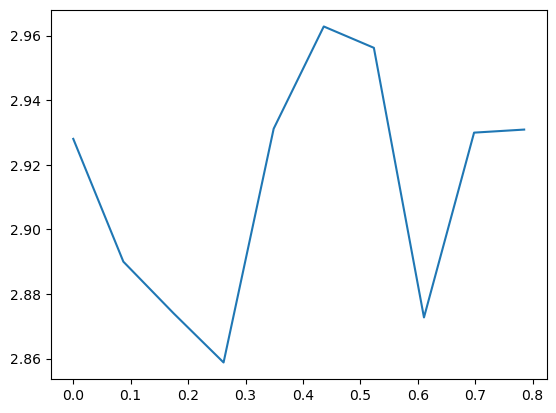

In [39]:
plt.plot(np.linspace(start=0, stop=np.pi * 0.25, num=10), spokes)
plt.show()

In [23]:
categorized_trajectories3 = categorize_diffusers_over_time(trajectories, 3, 0, step=i)
transition_matrix3 = calc_radialized_transition_matrix(categorized_trajectories3, 3, init_1=True)
Q = infinitesimal_generator(transition_matrix3)
P = transition_from_generator(Q)

print(transition_matrix3)
print("==========================")
print(Q)
print("==========================")
print(P)

[[9.34732067e-01 7.34335129e-03 7.34335129e-03 7.34335129e-03
  7.34335129e-03 7.34335129e-03 7.34335129e-03 7.34335129e-03
  7.34335129e-03 7.15905869e-04 7.15905869e-04 7.15905869e-04
  7.15905869e-04 7.15905869e-04 7.15905869e-04 7.15905869e-04
  7.15905869e-04 9.21463000e-05 9.21463000e-05 9.21463000e-05
  9.21463000e-05 9.21463000e-05 9.21463000e-05 9.21463000e-05
  9.21463000e-05 5.67054154e-05]
 [3.43288953e-01 1.70205110e-01 8.06045340e-02 2.87873336e-02
  1.43936668e-02 8.63620007e-03 1.43936668e-02 1.15149334e-02
  1.03634401e-01 5.18172004e-02 4.03022670e-02 1.72724001e-02
  8.63620007e-03 5.75746671e-03 8.63620007e-03 1.15149334e-02
  2.59086002e-02 8.63620007e-03 8.63620007e-03 8.63620007e-03
  5.75746671e-03 2.87873336e-03 5.75746671e-03 2.87873336e-03
  5.75746671e-03 5.75746671e-03]
 [3.31826087e-01 7.79130435e-02 1.64521739e-01 1.02956522e-01
  2.50434783e-02 1.11304348e-02 1.11304348e-02 1.11304348e-02
  1.39130435e-02 3.06086957e-02 6.12173913e-02 3.33913043e-02
  1.